## Setup

In [1]:
%pip install datatorch --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.9/96.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.2/65.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.9/140.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━

In [2]:
import datatorch as dt
from fastai.vision.all import *

## Classification

In [ ]:
path = untar_data(URLs.PETS)
path.ls()

(#2) [Path('/root/.fastai/data/oxford-iiit-pet/annotations'),Path('/root/.fastai/data/oxford-iiit-pet/images')]

In [ ]:
files = get_image_files(path/"images")
len(files)

7390

In [ ]:
files[0],files[6]

(Path('/root/.fastai/data/oxford-iiit-pet/images/yorkshire_terrier_91.jpg'),
 Path('/root/.fastai/data/oxford-iiit-pet/images/miniature_pinscher_197.jpg'))

In [ ]:
set_seed(99, True)
path = untar_data(URLs.PETS)/'images'
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2,
    label_func=lambda x: x[0].isupper(), item_tfms=Resize(224))

In [ ]:
img = PILImage.create('../images/cat.jpg')
print(f"Probability it's a cat: {learn.predict(img)[2][1].item():.6f}")

FileNotFoundError: [Errno 2] No such file or directory: '../images/cat.jpg'

## Segmentation

### fastai

In [ ]:
path = untar_data(URLs.CAMVID_TINY)

In [ ]:
dls = SegmentationDataLoaders.from_label_func(
    path, bs=8, fnames = get_image_files(path/"images"),
    label_func = lambda o: path/'labels'/f'{o.stem}_P{o.suffix}',
    codes = np.loadtxt(path/'codes.txt', dtype=str)
)

learn = unet_learner(dls, resnet34)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 118MB/s]


In [ ]:
learn.fine_tune(8)

In [ ]:
learn.show_results(max_n=6, figsize=(7,8))

### datatouch

In [3]:
from google.colab import userdata
datatorch_api_key = userdata.get('DATATORCH_API_KEY')

In [6]:
import os.path
from os import path

api = dt.api.ApiClient(datatorch_api_key)

# For the default schema named 'All-Coco'
# Define the path you want to create
path = "/root/dataset/bia4'"

# Create directories recursively
os.makedirs(path, exist_ok=True)

os.chdir('/root/dataset/bia4')
api.project('gierusalem/bia4').download('All-Coco')



100%|██████████| 10/10 [00:03<00:00,  2.76it/s]


In [3]:
import cv2
import json
import numpy as np

def get_mask(img_path):
    # Find image ID
    img_id = None
    for img in coco.dataset['images']:
        if Path(img['file_name']).name == img_path.name:
            img_id = img['id']
            break

    if not img_id: return None

    # Create mask from polygons
    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
    if not anns: return None

    img_info = coco.loadImgs(img_id)[0]
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

    for ann in anns:
        for poly in ann['segmentation']:
            points = np.array(poly).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [points], ann['category_id'])

    return PILMask.create(mask)

In [4]:
from pycocotools.coco import COCO

path = Path("/root/dataset/bia4")
coco = COCO(path/'All-Coco-1.json')

# Get image paths
image_paths = []
for img in coco.dataset['images']:
    img_path = path / img['file_name']
    if img_path.exists():
        image_paths.append(img_path)


dls = DataBlock(
        blocks=(ImageBlock, MaskBlock),
        get_items=lambda x: [p for p in image_paths if get_mask(p) is not None],
        get_y=get_mask,
        splitter=RandomSplitter(0.2),
        item_tfms=Resize(512),
        batch_tfms=aug_transforms(size=512)
    ).dataloaders(path, bs=8)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [5]:
# Create and train model
learn = unet_learner(dls, resnet50, metrics=DiceMulti(), n_out=len(coco.dataset['categories']))
learn.fine_tune(2, base_lr=1e-4)

epoch,train_loss,valid_loss,dice_multi,time


KeyboardInterrupt: 

In [ ]:
learn.show_results()  # Visualize predictions

In [ ]:
# Load image
image_path = '/root/dataset/bia4/'
img = PILImage.create(image_path)

# Predict
pred_mask, _, _ = learn.predict(img)

# Visualize
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pred_mask, cmap='nipy_spectral')
plt.title('Segmentation Mask')
plt.axis('off')

plt.show()

## Keypoints

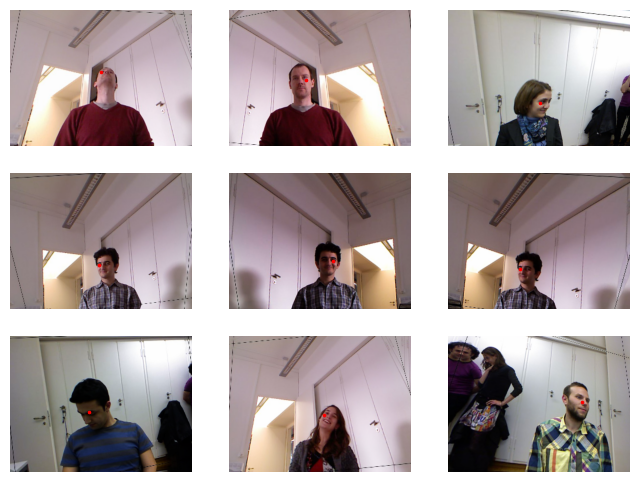

In [ ]:
path = untar_data(URLs.BIWI_HEAD_POSE)
img_files = get_image_files(path)

def img2pose(x): return Path(f'{str(x)[:-7]}pose.txt')
cal = np.genfromtxt(path/'01'/'rgb.cal', skip_footer=6)
def get_ctr(f):
    ctr = np.genfromtxt(img2pose(f), skip_header=3)
    c1 = ctr[0] * cal[0][0]/ctr[2] + cal[0][2]
    c2 = ctr[1] * cal[1][1]/ctr[2] + cal[1][2]
    return tensor([c1,c2])

biwi = DataBlock(
    blocks=(ImageBlock, PointBlock),
    get_items=get_image_files,
    get_y=get_ctr,
    splitter=FuncSplitter(lambda o: o.parent.name=='13'),
    batch_tfms=[*aug_transforms(size=(240,320)),
                Normalize.from_stats(*imagenet_stats)])

dls = biwi.dataloaders(path)
dls.show_batch(max_n=9, figsize=(8,6))

In [ ]:
learn = vision_learner(dls, resnet18, y_range=(-1,1))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 120MB/s]


In [ ]:
learn.lr_find()
learn.fine_tune(1, 1e-2)

epoch,train_loss,valid_loss,time


epoch,train_loss,valid_loss,time


In [ ]:
learn.show_results(ds_idx=1, nrows=3, figsize=(6,8))